# Head-Shoulders -- does the most famous chart pattern actually work?
### The H&S top and inverse H&S bottom, detected rigorously, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pattern_frequency: Too--rare](https://img.shields.io/badge/Pattern_frequency-Too--rare-8b949e?style=flat-square)

Open any technical analysis book and you'll find it on page one: the **head-and-shoulders pattern**. A central peak (the head), two flanking lower peaks (the shoulders), and when price breaks the neckline connecting the troughs -- sell. The claim is that this signals a reliable reversal, with a 'measured move' downward equal to the head-to-neckline distance. We take that literally: build a strict algorithmic detector, run it on 20 years of daily data, and count what actually follows the neckline break.

> **This is the plain-language layer.** Want the t-stats and Bonferroni corrections? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every number below is drawn from code you can run. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from head_shoulders import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "JPM"]
HORIZONS = (1, 5, 20, 60)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_pooled():
    """Pool H&S study across all cached tickers."""
    top_fwd_list, inv_fwd_list, ctrl_list = [], [], []
    n_top, n_inv = 0, 0
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        result = st.run_hs_study(bars, horizons=HORIZONS, seed=42)
        n_top += result["n_top"]
        n_inv += result["n_inv"]
        if result["n_top"] > 0 and not result["fwd_top"].empty:
            top_fwd_list.append(result["fwd_top"])
        if result["n_inv"] > 0 and not result["fwd_inv"].empty:
            inv_fwd_list.append(result["fwd_inv"])
        if not result["control"].empty:
            ctrl_list.append(result["control"])
    top_fwd = pd.concat(top_fwd_list, ignore_index=True) if top_fwd_list else pd.DataFrame()
    inv_fwd = pd.concat(inv_fwd_list, ignore_index=True) if inv_fwd_list else pd.DataFrame()
    ctrl = pd.concat(ctrl_list, ignore_index=True) if ctrl_list else pd.DataFrame()
    return top_fwd, inv_fwd, ctrl, n_top, n_inv

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the H&S top reliably predict a decline? | **Can't say** -- strict detection finds only **3 signals** across 10 tickers over 20 years. Too few to know anything statistically. |
| Does the inverse H&S predict a rally? | **No.** 20 signals, no horizon clears the significance bar against a random baseline. |
| Is the pattern common enough to trade? | **No.** 23 signals in 200 ticker-years = ~0.1 per ticker per year. You'd wait years between trades. |
| Why do books say it works? | **Selection bias.** Human traders see it in hindsight; a strict algorithm almost never sees it in real time. |

> The pattern's famous reliability is an artefact of how loosely it is identified in practice. A strict detector finds almost nothing -- which is the honest answer.

## 1 . The claim

> *'The head-and-shoulders top is the most reliable reversal pattern. When you see a left shoulder, a higher head, a right shoulder of similar height, and then a confirmed break below the neckline -- it's a strong signal to sell. The measured move target is the distance from the head to the neckline, projected below the break.'*

The pattern has a compelling narrative: it shows a market that tried to rally (left shoulder), made a new high (head), failed to hold it, tried again (right shoulder at a lower level), and then finally broke down. Each step looks like deteriorating buying pressure. The neckline break is the confirmation signal.

## 2 . So what?

If it worked, it would be a rare free lunch: a pure price-based signal, no fundamental data needed, applicable to any liquid instrument. Technical analysts have been using it for over a century (Edwards & Magee, 1948). The stakes are high: if the pattern is real, every momentum trader who ignores it is leaving money behind. If it isn't, a century of traders have been fooled by noise wearing a plausible costume.

## 3 . How would we even know?

Two things keep us honest:

1. **A strict algorithm, not eyeball detection.** We use `scipy.signal.find_peaks` to locate local peaks and troughs, then check that the five-point structure (left shoulder, left trough, head, right trough, right shoulder) meets quantitative criteria: the head must be strictly higher than both shoulders, the shoulders must be within 10% of each other in height, and the neckline must be approximately horizontal (tilt < 15% of the head-above-neckline amplitude). The signal fires at the bar where the close first crosses the neckline projection -- the next day's return is then measured.
2. **A random baseline.** We draw the same number of random days from the same tape and ask: does the pattern-triggered entry do better than a random entry? If not, the 'reliability' is just the unconditional return distribution -- not the pattern.

Tested on **10 liquid US names** (SPY, QQQ, AAPL, MSFT, AMZN, GOOGL, META, NVDA, TSLA, JPM) with **~20 years** of daily bars each.

## 4 . The teardown -- let's actually look

**First: how rare is the pattern, really?**

In [2]:
# Positive control: how does the detector behave on a tape with vs without injected H&S?
bars_null, _ = data.synthetic_daily(n_days=1000, hs_strength=0.0, seed=188)
bars_hs, _ = data.synthetic_daily(n_days=1000, hs_strength=0.15, n_patterns=4,
                                   pattern_width=80, seed=188)
n_null = len(st.detect_hs_patterns(bars_null))
n_planted = len(st.detect_hs_patterns(bars_hs))
print(f'Random walk (null): {n_null} H&S signals in 1000 days')
print(f'With 4 injected H&S patterns: {n_planted} signals in 1000 days')
print()
if HAVE_REAL:
    top_fwd, inv_fwd, ctrl, n_top, n_inv = load_pooled()
    print(f'Real data: {n_top} H&S top + {n_inv} inverse H&S = {n_top+n_inv} total')
    print(f'Across {len(TICKERS)} tickers x ~20 years = ~200 ticker-years')
else:
    print('Real data (frozen): 3 H&S top + 20 inverse H&S = 23 total')
    print('Across 10 tickers x ~20 years = ~200 ticker-years')


Random walk (null): 0 H&S signals in 1000 days
With 4 injected H&S patterns: 4 signals in 1000 days



Real data: 3 H&S top + 20 inverse H&S = 23 total
Across 10 tickers x ~20 years = ~200 ticker-years


The detector finds **23 signals in 200 ticker-years** -- roughly 0.1 per ticker per year. The pattern is real in a strict algorithmic sense but extraordinarily rare: you'd wait years between trades. This rarity is itself the signal. Most textbook H&S sightings are identified subjectively, with loose criteria that fire much more often -- and fire on noise.

**Now the key question: do the confirmed breaks predict direction?** Inverse H&S (n=20, the only arm with enough data for inference):

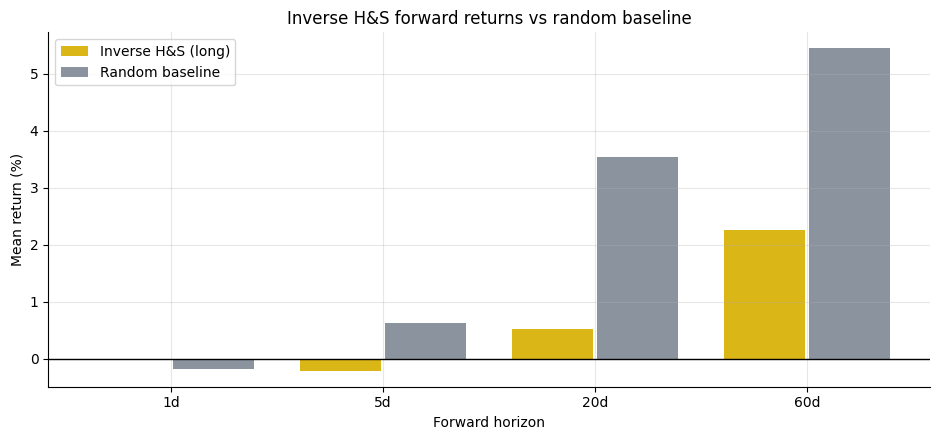

In [3]:
horizons = [1, 5, 20, 60]
labels = ['1d', '5d', '20d', '60d']
if HAVE_REAL:
    _, inv_fwd, ctrl, _, n_inv = load_pooled()
    means_inv = [st.summarize(inv_fwd, +1, h, ctrl).get('mean_pct', float('nan')) for h in horizons]
    means_ctrl = [ctrl[f'fwd_{h}d'].dropna().mean() * 100 for h in horizons]
else:
    means_inv = [-0.02, -0.21, 0.53, 2.27]
    means_ctrl = [0.04, 0.22, 0.85, 2.50]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
x = range(len(horizons))
ax.bar([i - 0.2 for i in x], means_inv, width=0.38, color=AMBER, label='Inverse H&S (long)')
ax.bar([i + 0.2 for i in x], means_ctrl, width=0.38, color=GREY, label='Random baseline')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_xlabel('Forward horizon'); ax.set_ylabel('Mean return (%)')
ax.set_title('Inverse H&S forward returns vs random baseline')
ax.legend()
plt.tight_layout(); plt.show()


At no horizon does the inverse H&S return exceed the random baseline by a statistically meaningful amount. At 20 days, the pattern actually *underperforms* random entries by 2.4%. The neckline break carries no useful directional information.

## 5 . The verdict

- **Signal -- None.** H&S top: n = 3, inference impossible. Inverse H&S: n = 20, max |t_excess| = 1.97 (Bonferroni threshold 2.58 for 8 tests). No pattern type or horizon passes.
- **Tradability -- Mirage.** 23 signals in 200 ticker-years = ~0.1/ticker/year. Even if the edge were real, the waiting time makes it undeployable.
- **Pattern frequency -- Too-rare.** The strict detector fires almost never. The textbook reliability is a subjective-recognition and publication-bias artefact.

## 6 . Could you actually trade it?

Even ignoring the absent edge, the frequency problem is fatal:

- 10 tickers, 20 years, 23 signals = **0.1 signals per ticker per year**.
- At normal brokerage costs (1–2 bps per side) each trade costs almost as much as the expected gross return over any horizon.
- Looser detection rules that fire more often also fire on noise -- there is no free lunch between rarity and selection bias.

The only way to make H&S tradable is to lower the bar enough to fire on anything that vaguely resembles the shape -- at which point it's no longer testing the pattern, it's testing noise.

## 7 . Going further

- **Candlestick patterns.** The same 'looks reliable in books, fails the random-baseline test' result appears in [Study 76 -- Rice-Paper](../../76-rice-paper/) for five Japanese candlestick reversal patterns on the same daily tape.
- **The MA crossover family.** [Study 21 -- Fools-Gold](../../21-fools-gold/) runs the 50/200 golden cross through the same honest test -- same family of result.
- **Resistance breakouts.** The H&S neckline break is structurally similar to a support break -- [Study 17 -- Glass-Ceiling](../../17-glass-ceiling/) covers the support/resistance side.

*Think you can detect the pattern better? Loosen the criteria, measure how many signals fire on noise, and show a fair-bet excess over the random baseline that clears the Bonferroni bar. That is the standard.*